In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("heart_cleveland_upload.csv")
print(df.shape)
df.head()

(297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [3]:
X = df.drop(columns=["condition"])
y = df["condition"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (237, 13)
Test: (60, 13)


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)
print("Training selesai!")

Training selesai!


In [6]:
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Sehat", "Sakit"]))

Accuracy: 0.7

Classification Report:
              precision    recall  f1-score   support

       Sehat       0.73      0.69      0.71        32
       Sakit       0.67      0.71      0.69        28

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60



In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="recall", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best recall (CV):", grid_search.best_score_)

Best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best recall (CV): 0.8160173160173161


In [8]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=["Sehat", "Sakit"]))

Accuracy: 0.7333333333333333

Classification Report:
              precision    recall  f1-score   support

       Sehat       0.77      0.72      0.74        32
       Sakit       0.70      0.75      0.72        28

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.74      0.73      0.73        60



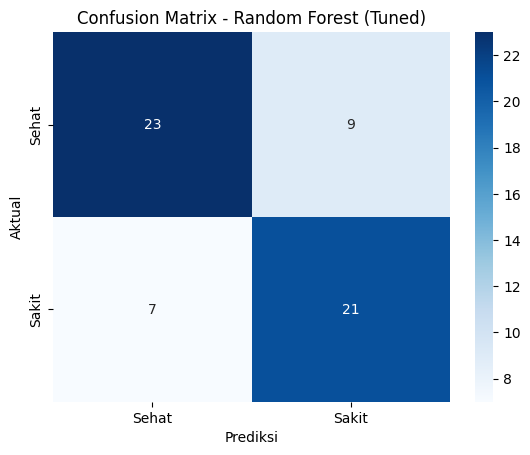

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Sehat", "Sakit"],
            yticklabels=["Sehat", "Sakit"])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.show()

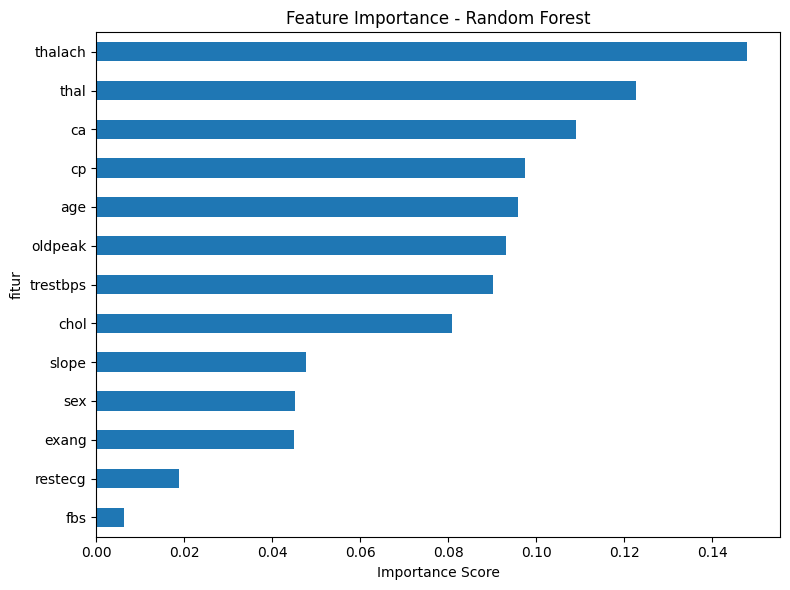

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Ambil feature importance dari model
rf_model = best_model.named_steps["model"]
importances = rf_model.feature_importances_
feature_names = X.columns

# Bikin dataframe dan urutkan
fi_df = pd.DataFrame({
    "fitur": feature_names,
    "importance": importances
}).sort_values("importance", ascending=True)

# Plot
fi_df.plot(kind="barh", x="fitur", y="importance", legend=False, figsize=(8,6))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [11]:
import joblib

joblib.dump(best_model, "model_jantung.joblib")
print("Model tersimpan!")

Model tersimpan!
